In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

/Users/dfasil/.pyenv/versions/3.11.10/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
#We prove in 01_data_prep we could join the lihtc data to hhousing data
#So lets bring in the housing df we created in that notebook

In [3]:
housing = pd.read_csv('../data/processed/housing_lihtc.csv', dtype={'join_key': str})

In [4]:
#Lets view the data
housing.head()

,join_key,yr_pis,new_li_units,n_projects,cum_li_units,State,year,zhvi_value
0,01001,2000,28.0,1,75.0,AL,2000,122006.919306
1,01001,2003,80.0,1,155.0,AL,2003,132888.041386
2,01001,2009,152.0,2,307.0,AL,2009,160543.685878
3,01003,2000,40.0,1,325.0,AL,2000,133831.967205
4,01003,2001,117.0,2,442.0,AL,2001,141370.630649


In [5]:
#Great so we have a few things to do before we can really start modeling
#First lets rename join_key to county_fips since we're no longer in the context of joining the datasets

In [6]:
housing = housing.rename(columns={'join_key':'county_fips'})

In [7]:
#For this analysis we want to compare prices
#But we should ensure we're comparing a value that's interpretable across all counties
#Plus we have a right skewed distribution with raw prices, so I'd like to work with log(prices)

In [8]:
#Lets get our log(zhvi) column

In [9]:
housing['log_zhvi_value'] = np.log(housing['zhvi_value'])

In [10]:
#How does the distribution look now?

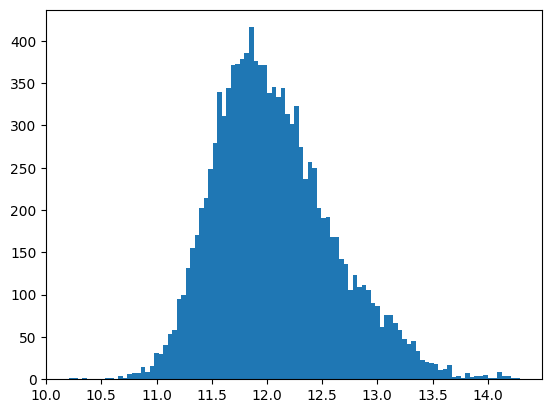

In [11]:
plt.hist(x=housing['log_zhvi_value'], bins=100)
plt.show()

In [12]:
#Transformed to a Normal distribution, easier to model and think through 

In [13]:
#To match that, let's log the cumulative units as well

In [14]:
#Using log1p to account for 0s
housing['log_cum_li_units'] = np.log1p(housing['cum_li_units'])

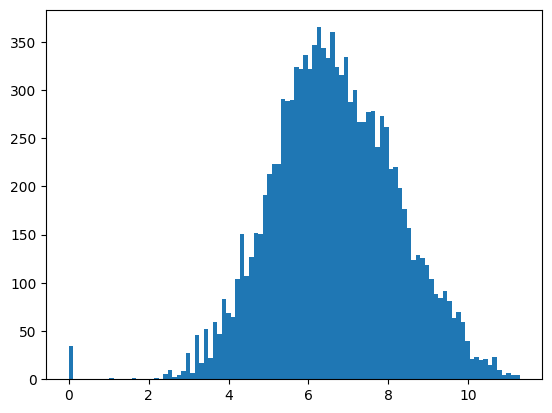

In [15]:
#Lets plot this distribution
plt.hist(x=housing['log_cum_li_units'], bins=100)
plt.show()

In [16]:
#Looks Normal as well

In [17]:
#The dataset is ready for modeling
#What we're modeling is the following:
#log(price) = alpha + beta1 * log(cum_li_units) + epsilon

In [1]:
#We have a lot of data, so we can set our priors to be a bit more informative

In [19]:
#Based on the plot above, the log(zhvi) values center around 12
#So we can use a prior for alpha to be Normal(12,2) to be somewhat informative
#We'll keep a weak prior for beta since we're saying we have no understanding of the effect of lihtc building

In [20]:
#Lets build our model

In [21]:
X = housing['log_cum_li_units'].values
y = housing['log_zhvi_value'].values

In [22]:
with pm.Model() as m:
    tau = pm.Gamma("tau", 0.001, 0.001)
    #We want std dev = 2, and tau = 1/(std dev)^2, so tau should be 1/4 or .25
    beta0 = pm.Normal("beta0_intercept", 12, tau=0.25)
    beta1 = pm.Normal("beta1_sqrt_ma", 0, tau=0.001)
    variance = pm.Deterministic("variance", 1 / tau)

    mu = beta0 + (beta1 * X)
    likelihood = pm.Normal("likelihood", mu=mu, tau=tau, observed=y)

    #Adding a random seed so the notebook is reproducable
    trace_pooled = pm.sample(random_seed=6420, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau, beta0_intercept, beta1_sqrt_ma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [23]:
#Lets see the summary
az.summary(trace_pooled, var_names=['beta0_intercept', 'beta1_sqrt_ma'], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0_intercept,10.982,0.019,10.945,11.022,0.001,0.0,1471.0,1711.0,1.0
beta1_sqrt_ma,0.164,0.003,0.158,0.169,0.000,0.0,1500.0,1658.0,1.0


In [24]:
#So this regression pools across all counties and states
#For example, beta0 has a mean of 10.982 which is ~$59k which is quite low

In [25]:
#Beta1 95% credible range is above 0 and hovers around 0.164 meaning 1% increase in lihtc construction leads to .164% increase in prices

In [26]:
#However states like CA, NY, etc have high home prices AND have more lihtc
#Not because they cause each other but because that's where the demand is

In [27]:
#We need to create a index for both county and state for the hierarchal model

In [28]:
#Lets pull the state code from the fips code
housing['state_code'] = housing['county_fips'].str[:2]

In [29]:
#Now we can create the indices for state and county
housing['state_idx'], state_labels = pd.factorize(housing['state_code'])
housing['county_idx'], county_labels = pd.factorize(housing['county_fips'])

In [30]:
#Lets store the number of states and counties
n_states = housing['state_idx'].nunique()
n_counties = housing['county_idx'].nunique()

In [31]:
#We need a "coords" dict to map our state and county indices for the hierarchal model

In [32]:
#Using the state code rather than FIPS
coords = {
    "state": housing['State'].unique(),
    "county": county_labels,
    "obs": np.arange(len(housing)),
}

In [33]:
#Now let's build our hierarchal model to account for county and state

In [34]:
#This will look similar to above with a couple additions
#But with priors on state and county distributions

In [35]:
#Counties get intercepts (whats baseline for this granular level
#Then as state adds more lihtc units, how does this affect the locale
#Counties within the same state can have wildly different baseline price levels


with pm.Model(coords=coords) as hierarchical_model:
    # --- Hyperpriors for county intercepts ---
    mu_alpha = pm.Normal("mu_alpha", 12, tau=0.25)
    tau_alpha = pm.Gamma("tau_alpha", 0.001, 0.001)
    
    # --- County intercepts (one per county) ---
    alpha = pm.Normal("alpha", mu=mu_alpha, tau=tau_alpha, dims="county")
    
    # --- Hyperpriors for state LIHTC slopes ---
    mu_beta = pm.Normal("mu_beta", 0, tau=0.001)
    tau_beta = pm.Gamma("tau_beta", 0.001, 0.001)
    
    # --- State slopes (one per state) ---
    beta = pm.Normal("beta", mu=mu_beta, tau=tau_beta, dims="state")
    
    # --- Noise (same as pooled model) ---
    tau = pm.Gamma("tau", 0.001, 0.001)
    
    # --- Linear model (use indexing!) ---
    mu = alpha[housing['county_idx'].values] + beta[housing['state_idx'].values] * X
    
    # --- Likelihood ---
    likelihood = pm.Normal("likelihood", mu=mu, tau=tau, observed=y)

    #Adding a random seed so the notebook is reproducable
    trace_hier = pm.sample(random_seed=6420, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, tau_alpha, alpha, mu_beta, tau_beta, beta, tau]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 36 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [36]:
az.summary(trace_hier, var_names=['mu_alpha', 'mu_beta', 'tau_alpha', 'tau_beta'], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,10.507,0.022,10.460,10.547,0.003,0.002,62.0,56.0,1.07
mu_beta,0.269,0.008,0.254,0.285,0.000,0.000,281.0,997.0,1.01
tau_alpha,6.355,0.240,5.887,6.824,0.013,0.004,352.0,1285.0,1.01
tau_beta,389.650,88.300,226.381,562.411,2.012,1.348,1818.0,2289.0,1.00


array([[<Axes: title={'center': 'mu_alpha'}>,
        <Axes: title={'center': 'mu_alpha'}>],
       [<Axes: title={'center': 'mu_beta'}>,
        <Axes: title={'center': 'mu_beta'}>],
       [<Axes: title={'center': 'tau_alpha'}>,
        <Axes: title={'center': 'tau_alpha'}>],
       [<Axes: title={'center': 'tau_beta'}>,
        <Axes: title={'center': 'tau_beta'}>]], dtype=object)

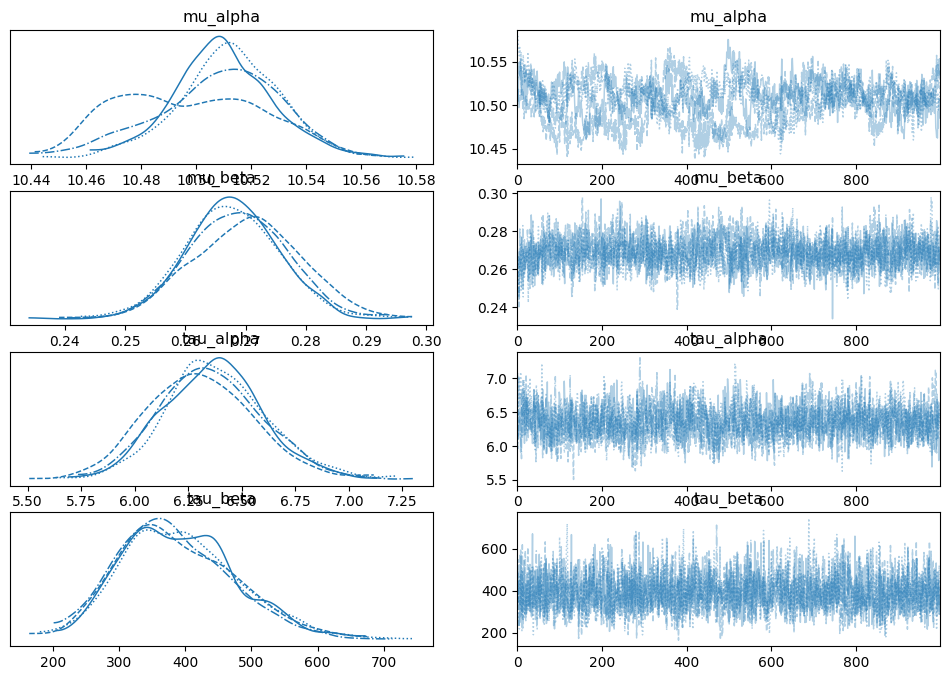

In [37]:
az.plot_trace(trace_hier, var_names=['mu_alpha', 'mu_beta', 'tau_alpha', 'tau_beta'])

array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

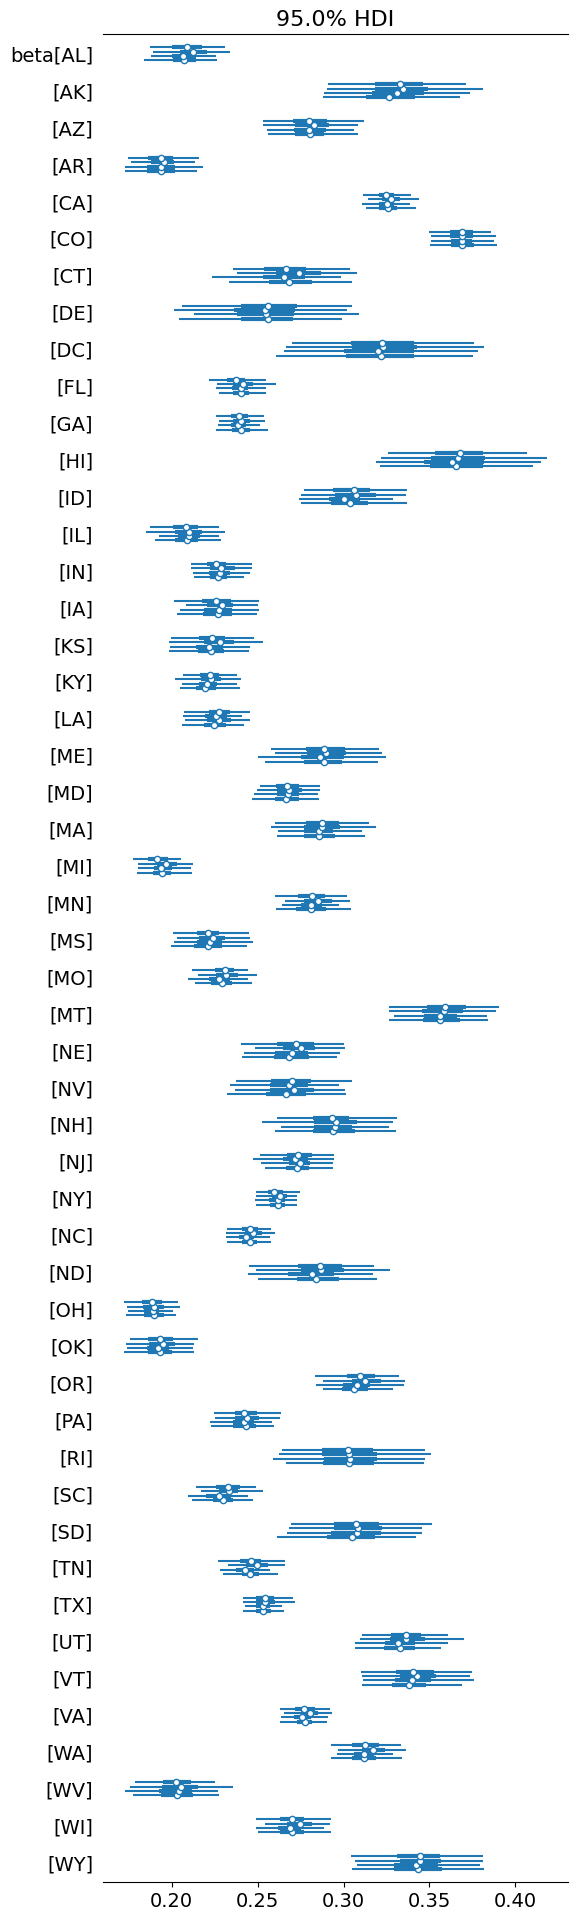

In [38]:
az.plot_forest(trace_hier, var_names=['beta'], hdi_prob=0.95)

<Axes: title={'center': 'mu_beta'}>

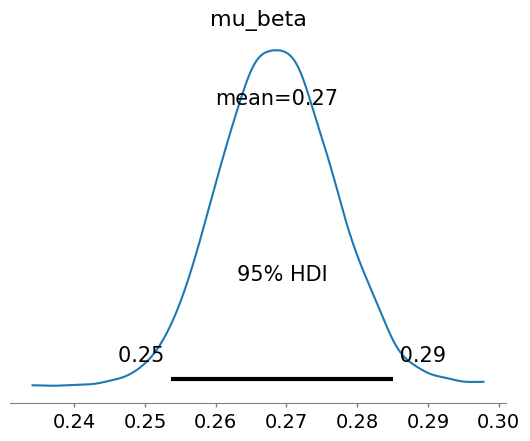

In [39]:
az.plot_posterior(trace_hier, var_names=['mu_beta'], hdi_prob=0.95)

In [40]:
#Commenting out for now since it takes a bit to run
# az.compare({"pooled": trace_pooled, "hierarchical": trace_hier})

In [41]:
#What we're likely seeing is lihtc and prices growing with housing demand
#Areas like CA and NY have high prices and a high need for afforable housing
#Thus get a lot of lihtc funding
#I'd like to see if we can control for population growth
#Idea being how does lihtc affect home prices relative to population growth

In [42]:
#We created a population growth dataset in 03_build_population_data so let's bring that csv in

In [43]:
pop = pd.read_csv('../data/processed/county_population_2000_2023.csv')

In [44]:
pop.head()

,county_fips,year,population,pop_growth
0,1001,2000,44021.0,NaN
1,1001,2001,44889.0,0.019718
2,1001,2002,45909.0,0.022723
3,1001,2003,46800.0,0.019408
4,1001,2004,48366.0,0.033462


In [45]:
#county_fips needs to be a string
pop['county_fips'] = pop['county_fips'].astype(str).str.zfill(5)

In [46]:
#Now lets merge the population data with the housing data

In [47]:
housing = housing.merge(pop, on=['county_fips', 'year'])

In [48]:
#Now we can include population in the model structure

In [49]:
#Need to re-define our data variables

In [50]:
# After the population merge and dropping NaNs:
housing = housing.dropna(subset=['pop_growth'])

# Redefine everything
X = housing['log_cum_li_units'].values
y = housing['log_zhvi_value'].values
pop_growth = housing['pop_growth'].values

# Re-factorize indices (row count changed!)
housing['state_idx'], state_labels = pd.factorize(housing['State'])
housing['county_idx'], county_labels = pd.factorize(housing['county_fips'])
n_states = housing['state_idx'].nunique()
n_counties = housing['county_idx'].nunique()

# Rebuild coords
coords = {
    "state": state_labels,
    "county": county_labels,
    "obs": np.arange(len(housing)),
}

In [51]:
#Same as county/state hierarchy but with population now

with pm.Model(coords=coords) as hierarchical_model:
    # --- Hyperpriors for county intercepts ---
    mu_alpha = pm.Normal("mu_alpha", 12, tau=0.25)
    tau_alpha = pm.Gamma("tau_alpha", 0.001, 0.001)
    
    # --- County intercepts (one per county) ---
    alpha = pm.Normal("alpha", mu=mu_alpha, tau=tau_alpha, dims="county")
    
    # --- Hyperpriors for state LIHTC slopes ---
    mu_beta = pm.Normal("mu_beta", 0, tau=0.001)
    tau_beta = pm.Gamma("tau_beta", 0.001, 0.001)
    
    # --- State slopes (one per state) ---
    beta = pm.Normal("beta", mu=mu_beta, tau=tau_beta, dims="state")
    
    # --- Noise (same as pooled model) ---
    tau = pm.Gamma("tau", 0.001, 0.001)

    # --- Pop Growth Variance ---
    gamma = pm.Normal("gamma", 0, tau=0.001)
    
    # --- Linear model (use indexing!) ---
    mu = alpha[housing['county_idx'].values] + beta[housing['state_idx'].values] * X + gamma * pop_growth
    
    # --- Likelihood ---
    likelihood = pm.Normal("likelihood", mu=mu, tau=tau, observed=y)

    #Adding a random seed so the notebook is reproducable
    trace_hier_pop = pm.sample(2000, tune=2000, random_seed=6420, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, tau_alpha, alpha, mu_beta, tau_beta, beta, tau, gamma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 53 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [52]:
az.summary(trace_hier_pop, var_names=['mu_alpha', 'mu_beta', 'tau_alpha', 'tau_beta'], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,10.606,0.024,10.559,10.655,0.003,0.001,72.0,121.0,1.05
mu_beta,0.251,0.008,0.234,0.267,0.001,0.000,238.0,912.0,1.02
tau_alpha,6.805,0.262,6.309,7.322,0.012,0.003,470.0,3079.0,1.01
tau_beta,409.272,89.570,242.037,581.869,1.582,0.963,3227.0,4802.0,1.00


array([[<Axes: title={'center': 'mu_alpha'}>,
        <Axes: title={'center': 'mu_alpha'}>],
       [<Axes: title={'center': 'mu_beta'}>,
        <Axes: title={'center': 'mu_beta'}>],
       [<Axes: title={'center': 'tau_alpha'}>,
        <Axes: title={'center': 'tau_alpha'}>],
       [<Axes: title={'center': 'tau_beta'}>,
        <Axes: title={'center': 'tau_beta'}>]], dtype=object)

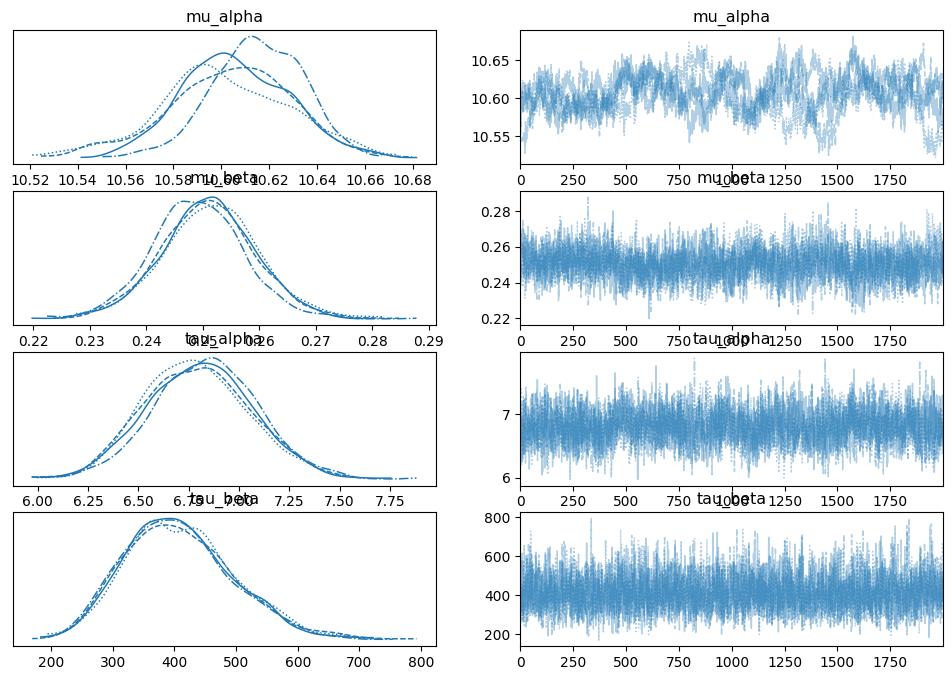

In [53]:
az.plot_trace(trace_hier_pop, var_names=['mu_alpha', 'mu_beta', 'tau_alpha', 'tau_beta'])

array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

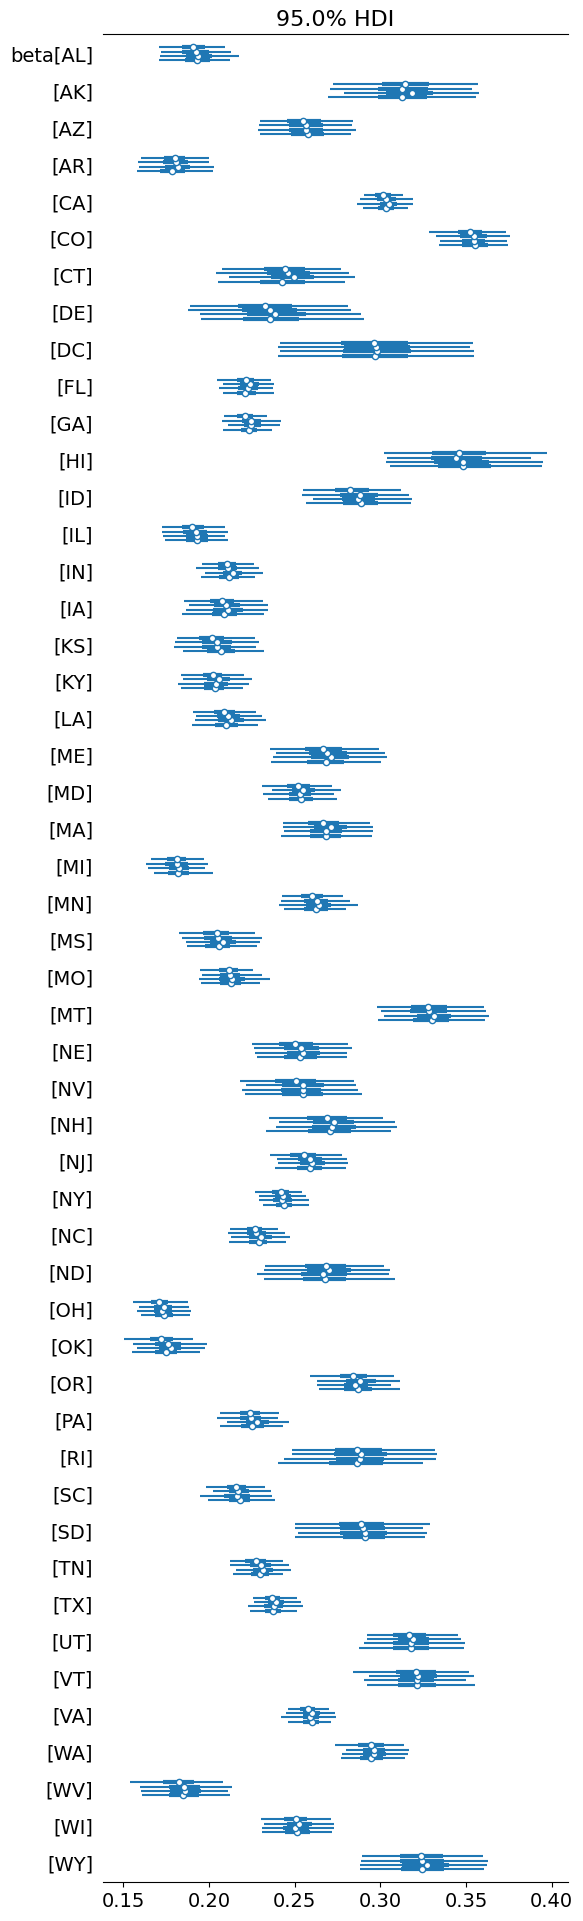

In [54]:
az.plot_forest(trace_hier_pop, var_names=['beta'], hdi_prob=0.95)

<Axes: title={'center': 'mu_beta'}>

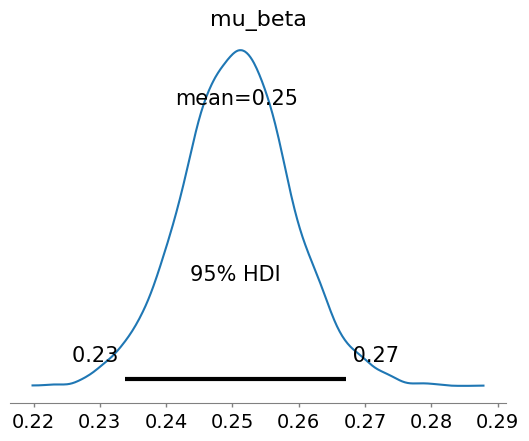

In [55]:
az.plot_posterior(trace_hier_pop, var_names=['mu_beta'], hdi_prob=0.95)

In [56]:
#Something else to consider is normalize by looking at units per capita

In [57]:
#Lets get cumulative units / pop * 1k and log the units
housing['lihtc_per_1k'] = (housing['cum_li_units'] / housing['population']) * 1000
housing['log_lihtc_per_1k'] = np.log1p(housing['lihtc_per_1k'])

In [58]:
#Confirm the distribution

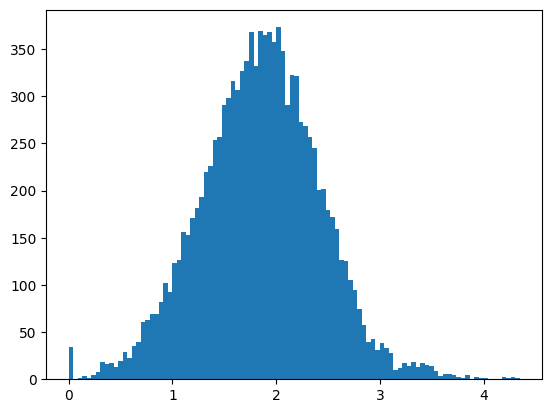

In [59]:
plt.hist(housing['log_lihtc_per_1k'], bins=100)
plt.show()

In [60]:
#Looks Normal

In [61]:
#Model will our Per 1k hierachal populaiton adjusted model

In [62]:
X = housing['log_lihtc_per_1k'].values

In [63]:
with pm.Model(coords=coords) as hierarchical_model:
    # --- Hyperpriors for county intercepts ---
    mu_alpha = pm.Normal("mu_alpha", 12, tau=0.25)
    tau_alpha = pm.Gamma("tau_alpha", 0.001, 0.001)
    
    # --- County intercepts (one per county) ---
    alpha = pm.Normal("alpha", mu=mu_alpha, tau=tau_alpha, dims="county")
    
    # --- Hyperpriors for state LIHTC slopes ---
    mu_beta = pm.Normal("mu_beta", 0, tau=0.001)
    tau_beta = pm.Gamma("tau_beta", 0.001, 0.001)
    
    # --- State slopes (one per state) ---
    beta = pm.Normal("beta", mu=mu_beta, tau=tau_beta, dims="state")
    
    # --- Noise (same as pooled model) ---
    tau = pm.Gamma("tau", 0.001, 0.001)

    # --- Pop Growth Variance ---
    gamma = pm.Normal("gamma", 0, tau=0.001)
    
    # --- Linear model (use indexing!) ---
    mu = alpha[housing['county_idx'].values] + beta[housing['state_idx'].values] * X + gamma * pop_growth
    
    # --- Likelihood ---
    likelihood = pm.Normal("likelihood", mu=mu, tau=tau, observed=y)

    #Adding a random seed so the notebook is reproducable
    trace_hier_pop_norm = pm.sample(2000, tune=2000, random_seed=6420, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, tau_alpha, alpha, mu_beta, tau_beta, beta, tau, gamma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 42 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [64]:
az.summary(trace_hier_pop_norm, var_names=['mu_alpha', 'mu_beta', 'tau_alpha', 'tau_beta'], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,11.278,0.015,11.250,11.308,0.001,0.000,525.0,1300.0,1.0
mu_beta,0.401,0.022,0.360,0.445,0.000,0.000,4639.0,5145.0,1.0
tau_alpha,6.212,0.225,5.782,6.665,0.004,0.002,3016.0,5323.0,1.0
tau_beta,49.387,10.576,28.974,69.554,0.132,0.139,6306.0,4962.0,1.0


array([[<Axes: title={'center': 'mu_alpha'}>,
        <Axes: title={'center': 'mu_alpha'}>],
       [<Axes: title={'center': 'mu_beta'}>,
        <Axes: title={'center': 'mu_beta'}>],
       [<Axes: title={'center': 'tau_alpha'}>,
        <Axes: title={'center': 'tau_alpha'}>],
       [<Axes: title={'center': 'tau_beta'}>,
        <Axes: title={'center': 'tau_beta'}>]], dtype=object)

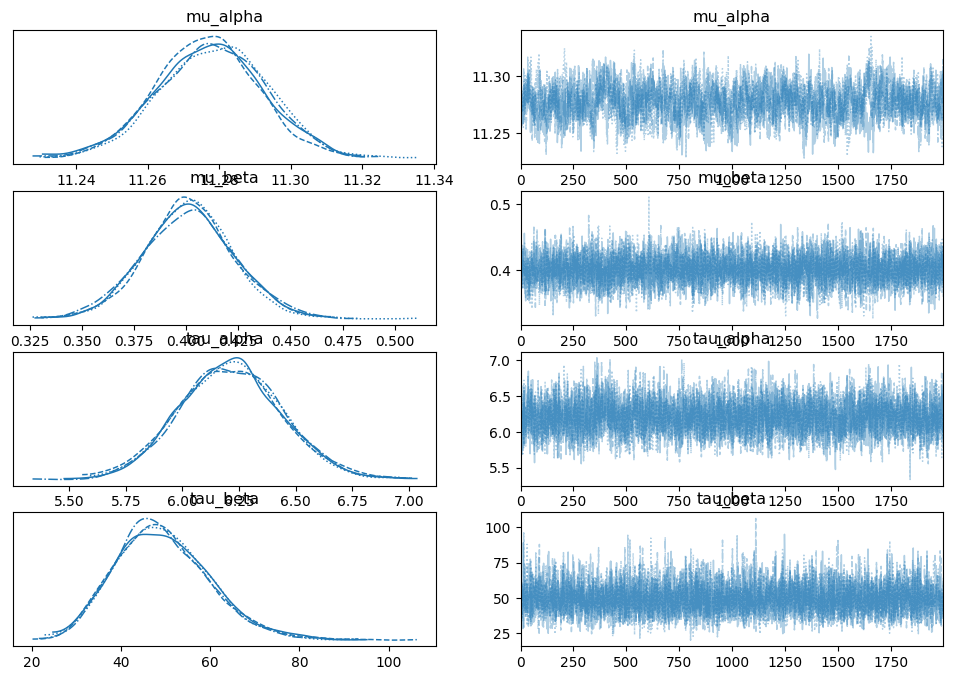

In [65]:
az.plot_trace(trace_hier_pop_norm, var_names=['mu_alpha', 'mu_beta', 'tau_alpha', 'tau_beta'])
# plt.savefig('../reports/figures/housing_plot_trace.jpg', bbox_inches="tight")

array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

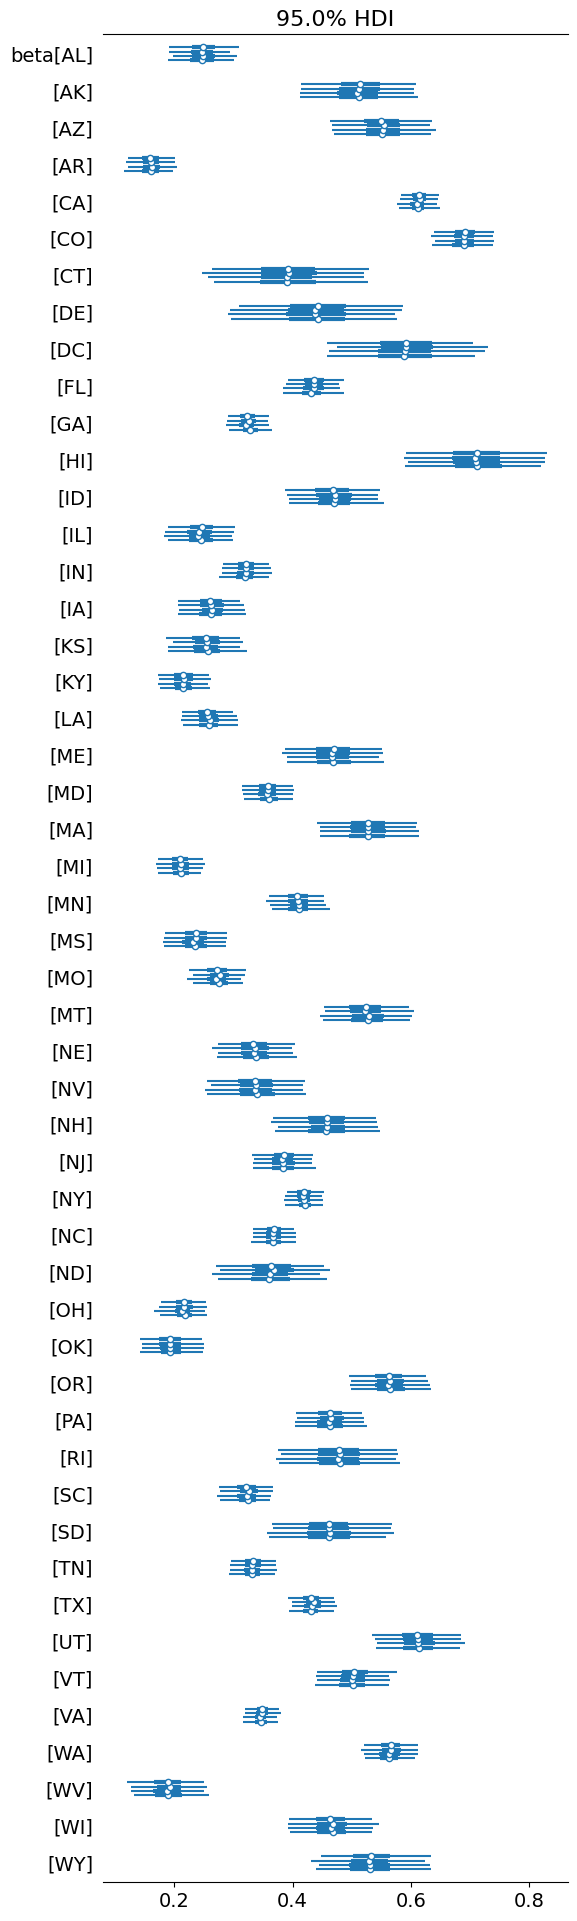

In [66]:
az.plot_forest(trace_hier_pop_norm, var_names=['beta'], hdi_prob=0.95)
# plt.savefig('../reports/figures/housing_plot_forest.jpg', bbox_inches="tight")

<Axes: title={'center': 'mu_beta'}>

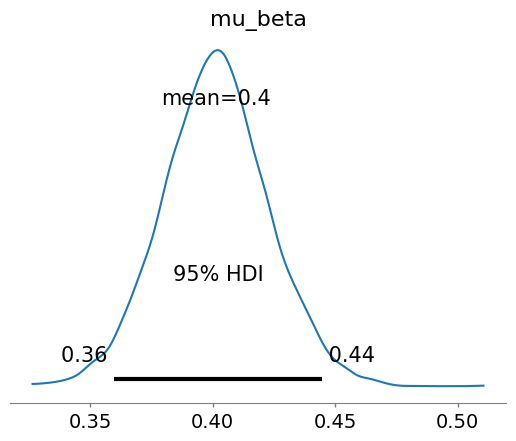

In [67]:
az.plot_posterior(trace_hier_pop_norm, var_names=['mu_beta'], hdi_prob=0.95)
# plt.savefig('../reports/figures/housing_plot_posterior.jpg', bbox_inches="tight")

In [68]:
az.compare({"Hierarchy w Pop": trace_hier_pop, "Hierarchy w Pop and Norm": trace_hier_pop_norm})

/Users/dfasil/.pyenv/versions/3.11.10/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/dfasil/.pyenv/versions/3.11.10/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Hierarchy w Pop and Norm,0,1688.173663,1693.296933,0.000000,0.475949,91.594531,0.000000,True,log
Hierarchy w Pop,1,1669.940946,1698.864566,18.232717,0.524051,92.198394,31.474252,True,log


In [69]:
#For full comparison sake let's make a pooled model using log(units per capita)

In [70]:
with pm.Model() as m:
    tau = pm.Gamma("tau", 0.001, 0.001)
    #We want std dev = 2, and tau = 1/(std dev)^2, so tau should be 1/4 or .25
    beta0 = pm.Normal("beta0_intercept", 12, tau=0.25)
    beta1 = pm.Normal("beta1_sqrt_ma", 0, tau=0.001)
    variance = pm.Deterministic("variance", 1 / tau)
    #For population variance
    gamma = pm.Normal("gamma", 0, tau=0.001)

    mu = beta0 + (beta1 * X) + gamma * pop_growth
    likelihood = pm.Normal("likelihood", mu=mu, tau=tau, observed=y)

    #Adding a random seed so the notebook is reproducable
    trace_pooled_norm = pm.sample(random_seed=6420, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau, beta0_intercept, beta1_sqrt_ma, gamma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


In [71]:
az.summary(trace_pooled_norm, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0_intercept,11.706,0.016,11.676,11.738,0.000,0.000,2108.0,2381.0,1.0
beta1_sqrt_ma,0.172,0.008,0.157,0.188,0.000,0.000,2179.0,2284.0,1.0
gamma,7.799,0.327,7.174,8.479,0.006,0.006,2774.0,2043.0,1.0
tau,3.708,0.049,3.615,3.803,0.001,0.001,2894.0,2197.0,1.0
variance,0.270,0.004,0.263,0.277,0.000,0.000,2894.0,2197.0,1.0


In [72]:
az.compare({"Pooled w Pop and Norm":trace_pooled_norm, "Hierarchy w Pop and Norm": trace_hier_pop_norm})

/Users/dfasil/.pyenv/versions/3.11.10/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/dfasil/.pyenv/versions/3.11.10/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Hierarchy w Pop and Norm,0,1688.173663,1693.296933,0.000000,0.992517,91.594531,0.000000,True,log
Pooled w Pop and Norm,1,-8773.542661,11.713373,10461.716325,0.007483,93.454407,123.091423,True,log


In [73]:
#So we see that hierarchy with population growth and norm helps with the modeling predictive power
#But one thing to note is that inflation would cause housing costs to increase regardless
#So we should try to control for housing costs that come from inflation

In [74]:
#In 05_build_inflation_data I was able to pull CPI less-housing per month
#I then annualized by taking the average for each year

In [75]:
#Lets bring that in and join to our dataset

In [76]:
inflation_annual = pd.read_csv('../data/processed/inflation_annual_2000_2026.csv')

In [77]:
inflation_annual.head()

,year,cpi_index
0,2000,165.725000
1,2001,169.741667
2,2002,170.816667
3,2003,174.583333
4,2004,179.275000


In [78]:
housing = housing.merge(inflation_annual, on=['year'])

In [79]:
housing.head()

,county_fips,yr_pis,new_li_units,n_projects,cum_li_units,State,year,zhvi_value,log_zhvi_value,log_cum_li_units,state_code,state_idx,county_idx,population,pop_growth,lihtc_per_1k,log_lihtc_per_1k,cpi_index
0,01001,2003,80.0,1,155.0,AL,2003,132888.041386,11.797262,5.049856,01,0,0,46800.0,0.019408,3.311966,1.461394,174.583333
1,01001,2009,152.0,2,307.0,AL,2009,160543.685878,11.986321,5.730100,01,0,0,54135.0,0.016105,5.671008,1.897771,203.301250
2,01003,2001,117.0,2,442.0,AL,2001,141370.630649,11.859140,6.093570,01,0,1,144875.0,0.024996,3.050906,1.398941,169.741667
3,01003,2002,68.0,1,510.0,AL,2002,145925.403095,11.890851,6.236370,01,0,1,147957.0,0.021274,3.446947,1.492218,170.816667
4,01003,2005,104.0,1,614.0,AL,2005,180008.418759,12.100759,6.421622,01,0,1,162183.0,0.037865,3.785847,1.565663,186.050000


In [80]:
#In order to calculate the "real" housing price, we need to set a base price index to calculate from
#The oldest year is 2001 so we'll use that as the base (set as standalone variable)

In [81]:
base_cpi = housing[housing['year'] == housing['year'].min()]['cpi_index'].values[0]

In [82]:
#Now for each row I calculate the "real price"
housing['zhvi_adj'] = housing['zhvi_value'] / (housing['cpi_index'] / base_cpi)

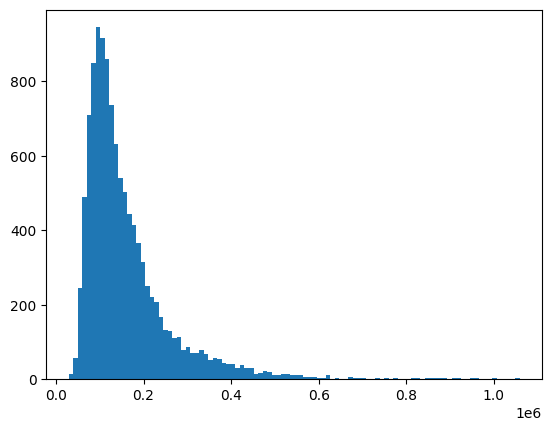

In [83]:
#Lets see the distribution of "real" zhvi to confirm it's still right skewed (meaning we need to log the values)
plt.hist(housing['zhvi_adj'], bins=100)
plt.show()

In [84]:
#Great, now let's log the values and plot that

In [85]:
housing['log_zhvi_adj'] = np.log(housing['zhvi_adj'])

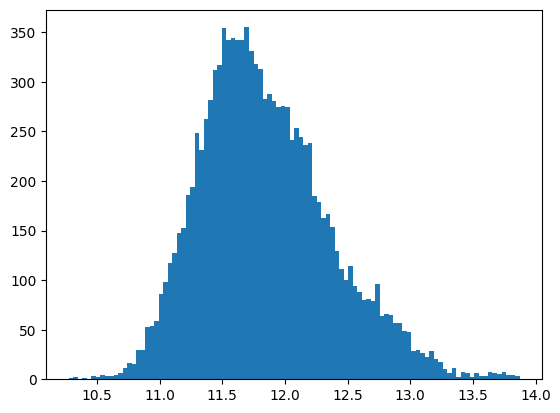

In [86]:
plt.hist(housing['log_zhvi_adj'], bins=100)
plt.show()

In [87]:
#Distribution of Normal, values come down a bit, hovering closer to 11.75

In [88]:
#Now we're ready for our Bayesian model

In [89]:
y = housing['log_zhvi_adj'].values

In [90]:
with pm.Model(coords=coords) as hierarchical_model:
    # --- Hyperpriors for county intercepts ---
    mu_alpha = pm.Normal("mu_alpha", 12, tau=0.25)
    tau_alpha = pm.Gamma("tau_alpha", 0.001, 0.001)
    
    # --- County intercepts (one per county) ---
    alpha = pm.Normal("alpha", mu=mu_alpha, tau=tau_alpha, dims="county")
    
    # --- Hyperpriors for state LIHTC slopes ---
    mu_beta = pm.Normal("mu_beta", 0, tau=0.001)
    tau_beta = pm.Gamma("tau_beta", 0.001, 0.001)
    
    # --- State slopes (one per state) ---
    beta = pm.Normal("beta", mu=mu_beta, tau=tau_beta, dims="state")
    
    # --- Noise (same as pooled model) ---
    tau = pm.Gamma("tau", 0.001, 0.001)

    # --- Pop Growth Variance ---
    gamma = pm.Normal("gamma", 0, tau=0.001)
    
    # --- Linear model (use indexing!) ---
    mu = alpha[housing['county_idx'].values] + beta[housing['state_idx'].values] * X + gamma * pop_growth
    
    # --- Likelihood ---
    likelihood = pm.Normal("likelihood", mu=mu, tau=tau, observed=y)

    #Adding a random seed so the notebook is reproducable
    trace_hier_pop_norm_adj = pm.sample(2000, tune=2000, random_seed=6420, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, tau_alpha, alpha, mu_beta, tau_beta, beta, tau, gamma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 42 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [91]:
az.summary(trace_hier_pop_norm_adj, var_names=['mu_alpha', 'mu_beta', 'tau_alpha', 'tau_beta'], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,11.497,0.013,11.472,11.522,0.001,0.000,612.0,1591.0,1.0
mu_beta,0.130,0.020,0.090,0.168,0.000,0.000,4094.0,4121.0,1.0
tau_alpha,7.617,0.281,7.081,8.166,0.005,0.003,3818.0,5788.0,1.0
tau_beta,56.136,12.016,33.692,79.623,0.145,0.140,6849.0,5556.0,1.0


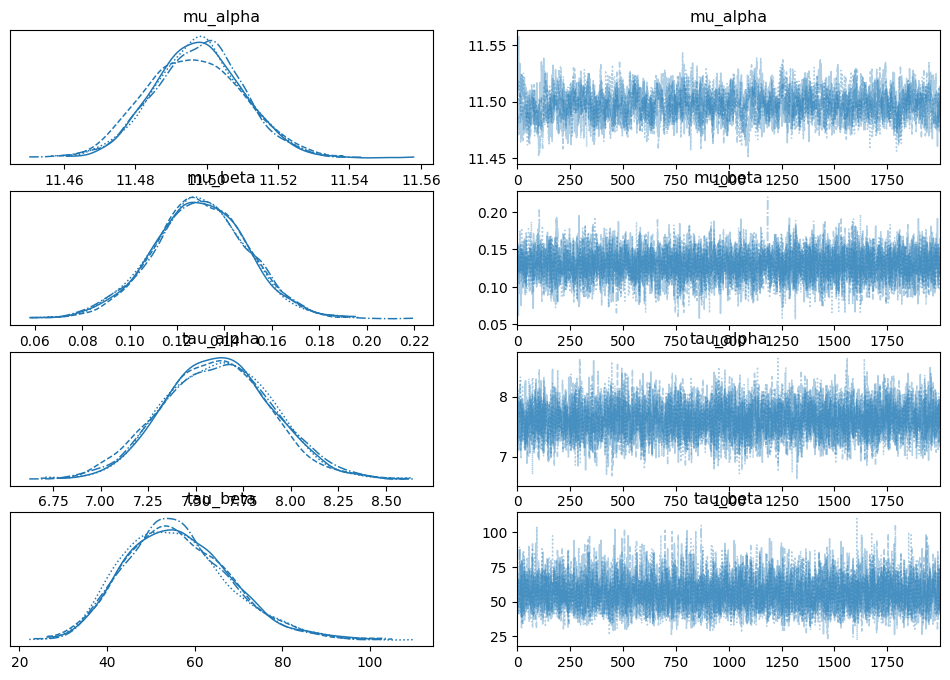

In [92]:
az.plot_trace(trace_hier_pop_norm_adj, var_names=['mu_alpha', 'mu_beta', 'tau_alpha', 'tau_beta'])
plt.savefig('../reports/figures/housing_plot_trace.jpg', bbox_inches="tight")

<Figure size 800x1600 with 0 Axes>

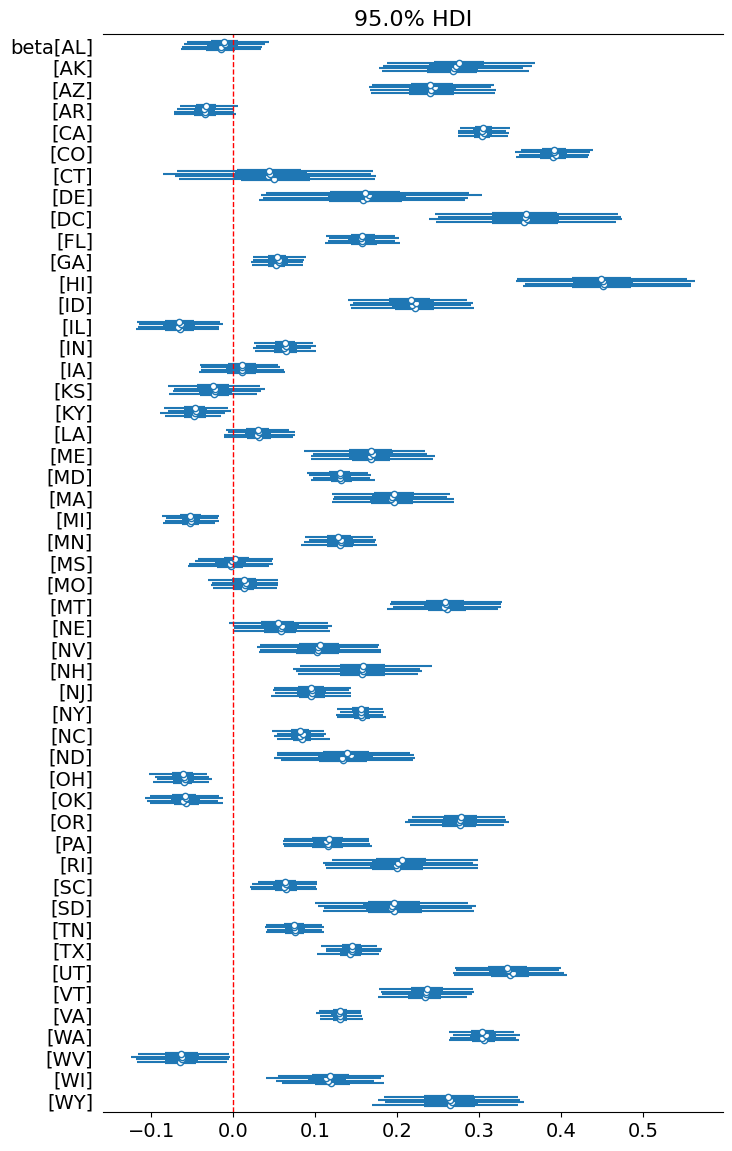

In [101]:
plt.gcf().set_size_inches(8, 16)
az.plot_forest(trace_hier_pop_norm_adj, var_names=['beta'], hdi_prob=0.95, figsize=(8, 14))
plt.axvline(0, color='red', linestyle='--', linewidth=1)
# plt.savefig('../reports/figures/housing_plot_forest.jpg', bbox_inches="tight")

<Axes: title={'center': 'mu_beta'}>

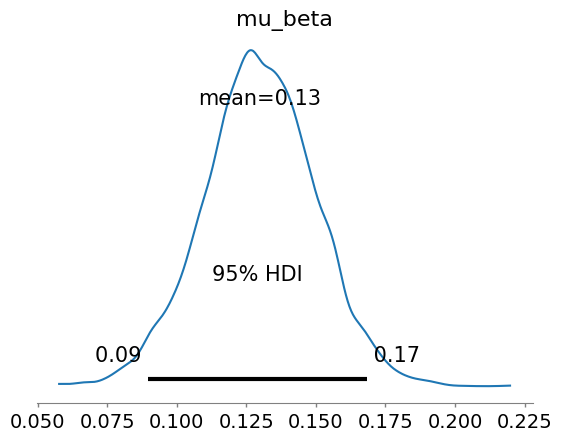

In [96]:
az.plot_posterior(trace_hier_pop_norm_adj, var_names=['mu_beta'], hdi_prob=0.95)
# plt.savefig('../reports/figures/housing_plot_posterior.jpg', bbox_inches="tight")

In [95]:
az.compare({"Hierarchy w Pop": trace_hier_pop, "Hierarchy w Pop and Norm": trace_hier_pop_norm, "Hierarchy w Pop and Norm Adj":trace_hier_pop_norm_adj})

/Users/dfasil/.pyenv/versions/3.11.10/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/dfasil/.pyenv/versions/3.11.10/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/dfasil/.pyenv/versions/3.

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Hierarchy w Pop and Norm Adj,0,3287.181185,1632.715735,0.000000,9.958449e-01,88.373196,0.000000,True,log
Hierarchy w Pop and Norm,1,1688.173663,1693.296933,1599.007522,2.256614e-10,91.594531,46.872271,True,log
Hierarchy w Pop,2,1669.940946,1698.864566,1617.240239,4.155098e-03,92.198394,55.635682,True,log
